In [10]:
import cutlass 
import torch 
import cutlass.cute as cute 
from cutlass.cute.runtime import from_dlpack
import cute_viz

In [11]:
@cute.kernel 
def tiled_mma_kern(gA:cute.Tensor, gB:cute.Tensor,gC:cute.Tensor, tiled_mma: cute.TiledMma):
  t,_,_ = cute.arch.thread_idx()
  thread_mma = tiled_mma.get_slice(t)
  thread_slice_A = thread_mma.partition_A(gA)
  thread_slice_B = thread_mma.partition_B(gB)
  thread_slice_C = thread_mma.partition_C(gC)
  print(thread_slice_A.layout) 
  print(thread_slice_B.layout)
  print(thread_slice_C.layout)
  tCrA = tiled_mma.make_fragment_A(thread_slice_A)
  print(tCrA.shape)
  tCrB = tiled_mma.make_fragment_B(thread_slice_B)
  tCrC = tiled_mma.make_fragment_C(thread_slice_C)
  tCrC.fill(0.0)
  cute.autovec_copy(thread_slice_A, tCrA)
  cute.autovec_copy(thread_slice_B, tCrB)
  #for k in range(tCrA.shape[2]):
  cute.gemm(tiled_mma, tCrC, tCrA[None,None,None], tCrB[None,None,None], tCrC)
  cute.autovec_copy(tCrC, thread_slice_C)

In [19]:
@cute.jit 
def tiled_mma_launcher(gA:cute.Tensor, gB:cute.Tensor, gC:cute.Tensor): 
  op = cute.nvgpu.warp.MmaF16BF16Op(
    cutlass.BFloat16,          # fp16
    cutlass.Float32,        # fp32
    (16, 8, 16)      # mma_inst_mnk
  ) 
  permutation_mnk = (32,16,64)
  atom_layout = (1,2,1)
  tC = cute.make_layout(atom_layout)
  tiled_mma = cute.make_tiled_mma(op, tC, permutation_mnk=permutation_mnk)
  #cute_viz.display_tiled_mma(tiled_mma,(64,32,64))
  cute_viz.display_tv_layout(tiled_mma.tv_layout_A,(16,16))
  tiled_mma_kern(gA,gB,gC,tiled_mma).launch(grid = [1,1,1], block =[128,1,1])
  print(tiled_mma)  
    

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0

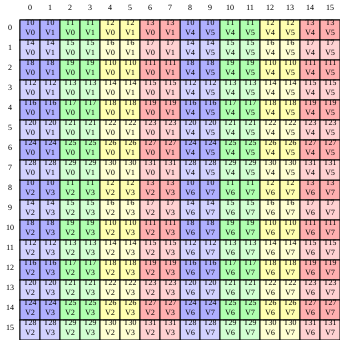

((2,2,2),2,4):((1,512,8),1024,16)
((2,2),1,4):((16,128),0,256)
((2,2),2,1):((1,128),256,0)
((2, 2, 2), 2, 4)
Tiled MMA
  Thr Layout VMNK: (32,1,2,1):(1,0,32,0)
  Permutation MNK: (32:1,16:1,64:1)
MMA Atom
  ThrID:           32:1
  Shape MNK:       (16,8,16)
  TV Layout A:     ((4,8),(2,2,2)):((32,1),(16,8,128))
  TV Layout B:     ((4,8),(2,2)):((16,1),(8,64))
  TV Layout C:     ((4,8),(2,2)):((32,1),(16,8))
tensor([[-2.8038e+00, -1.0205e+01,  4.5380e+00, -2.7672e+00, -8.9688e+00,
          2.6981e-01, -6.2778e+00,  2.4187e+00,  4.8715e+00,  4.6121e+00,
          6.8458e+00,  4.6078e+00, -9.0905e+00, -1.6392e+01,  6.5815e+00,
          1.4211e+01],
        [ 3.0217e+00, -1.4600e+00, -2.0728e+00,  3.6130e+00,  3.8541e+00,
          1.3644e-01,  2.3976e+00,  1.3722e+01, -2.0910e+00,  9.0149e+00,
         -3.2408e+00,  1.6708e+00, -5.9409e+00,  1.0061e+01,  1.1249e+01,
          1.8380e+01],
        [-5.2353e+00,  8.1154e+00,  1.3558e+00,  1.3980e+01, -2.9229e+00,
          3.3332e+00,  6.

In [20]:
M = 32
N = 16
K = 64

a = torch.randn(M, K, device="cuda", dtype=torch.bfloat16)
b = torch.randn(K, N, device="cuda", dtype=torch.bfloat16).T
c = torch.zeros(M, N, device="cuda", dtype=torch.float32)
print(c)
a_ = from_dlpack(a, assumed_align=16)
b_ = from_dlpack(b, assumed_align=16)
c_ = from_dlpack(c, assumed_align=16)

tiled_mma_kern_ = cute.compile(tiled_mma_launcher, a_, b_, c_)
tiled_mma_kern_(a_, b_, c_)
print(c)
print(torch.matmul(a.float(),b.transpose(0,1).float()))
print(torch.testing.assert_close(c, torch.matmul(a.float(),b.transpose(0,1).float())))